# This notebook was used to generate some miscellaneous plots

In [ ]:
import numpy as np
import sys
import time
import h5py
from tqdm import tqdm

import numpy as np
import re
from math import ceil
from sklearn.metrics import average_precision_score
from torch.utils.data import Dataset
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import pickle
#import pickle5 as pickle

from sklearn.model_selection import train_test_split

from scipy.sparse import load_npz
from glob import glob

from transformers import get_constant_schedule_with_warmup
from sklearn.metrics import precision_score,recall_score,accuracy_score

from src.train import trainModel
from src.dataloader import getData,spliceDataset,h5pyDataset,collate_fn, getDataPointListFull
from src.weight_init import keras_init
from src.losses import categorical_crossentropy_2d
from src.model import SpliceFormer, SpliceAI_10K
from src.evaluation_metrics import print_topl_statistics
import copy

In [2]:
data_dir = '../Data'
SL=5000
CL_max=40000
setType = 'test'
annotation_test, transcriptToLabel_test, seqData = getData(data_dir, setType) 

In [5]:
BATCH_SIZE = 1
specific_anno = annotation_test[annotation_test['name'].apply(lambda x: x.split('--')[0])=='CFTR']

In [20]:
from matplotlib.colors import LogNorm
from matplotlib.colors import PowerNorm
#norm=PowerNorm(gamma=0.1)

def plot_data(data, title, size):

    fig_width = 15  # You can tune this value
    fig_height = size  # One unit per row
    aspect_ratio = 45000 / fig_width
    fig, ax = plt.subplots(figsize=(20, 4))

    # Plot the data as an image
    cax = ax.imshow(data, cmap='gray', aspect='auto', interpolation='none')

    # Set y-axis labels
    ax.set_yticks([i for i in range(size)])
    if size == 4:
        labels = ['A', 'C', 'G', 'T']
    else:
        labels = ['Acceptor', 'Donor']
    ax.set_yticklabels(labels)

    # Optional: remove x-axis ticks to declutter
    # ax.set_xticks([])

    # Label and display
    ax.set_xlabel('Position')
    ax.set_title(f'{title} One-hot Encoding Grid (1 = white, 0 = black)')
    plt.tight_layout()
    plt.savefig('../Results/one_hot_encode.png',dpi=400)
    plt.show()
    plt.close()

/Users/douglasflorizone/Summer 2025 Research/Code/Spliceformer/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


(array([20184, 44400]),)


  0%|          | 0/38 [00:00<?, ?it/s]

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0,

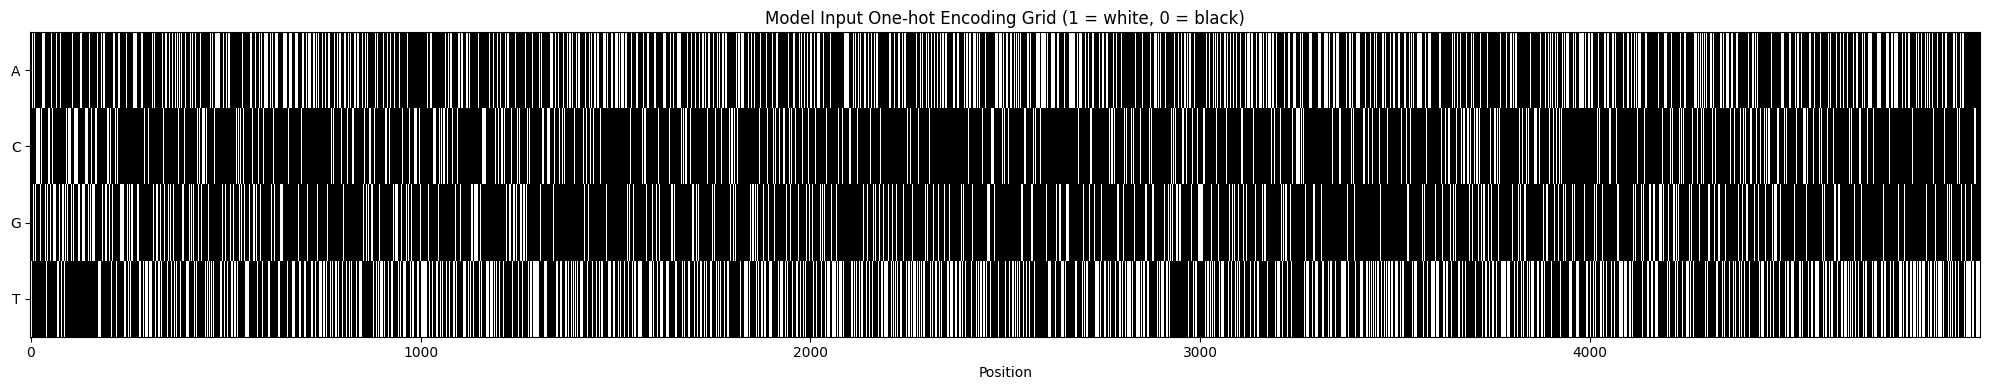

  0%|          | 0/38 [00:00<?, ?it/s]


NameError: name 'device' is not defined

In [22]:
test_dataset = spliceDataset(getDataPointListFull(specific_anno,transcriptToLabel_test,SL,CL_max,shift=SL))
test_dataset.seqData = seqData
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
all_data = list(test_loader)
print(np.nonzero(all_data[0][1][0,2,:].tolist()))
l = 1
for i,(batch_chunks,target_chunks) in enumerate(tqdm(test_loader)):
    print(batch_chunks[0,1,20000:25000].tolist())
    print(torch.nonzero(target_chunks[0,2,20000:]))
    plot_data(batch_chunks[0,:,20000:25000], 'Model Input',4)
    # plot_data(target_chunks[0,1:,20000:25000], 'Labels', 2)

    batch_features = batch_chunks.to(torch.float32).to(device)      # shape: [1, 4, 45000]
    output = ([model_m(batch_features)[0].detach()])
    output = torch.stack(output)
    output = torch.mean(output,dim=0)
    print(output[0,2,torch.argsort(output[0,2,:], descending=True)].tolist())
    plot_data(output[0,:,:], 'Model Output', 2)
    targets = torch.squeeze(target_chunks.to(torch.float32).to(device), dim=0)  # shape: [3, 45000]
    # print(batch_features[0,0,:].tolist())
    signal = batch_features[0].sum(dim=0)  # shape: [45000]
    nonzero_positions = torch.nonzero(signal > 0).squeeze()
    print("Transcript spans:", nonzero_positions.min().item(), "to", nonzero_positions.max().item())
    l += 1

    if l >1:
        break
    # batch_chunks = torch.transpose(batch_chunks.to(torch.float32).to(device),1,1)
    # target_chunks = torch.transpose(target_chunks.to(torch.float32).to(device),1,1)
    # batch_chunks = torch.split(batch_chunks, BATCH_SIZE, dim=0)
    # target_chunks = torch.split(target_chunks, BATCH_SIZE, dim=0)
    # targets = torch.squeeze(torch.cat(target_chunks,dim=2),dim=0)
    # for j in range(len(batch_chunks)):
    #     batch_features = batch_chunks[j]
    #     #targets = target_chunks[j]
    #     plotAttentionWeights(model_m,batch_features,targets,j*5000,'CFTR_{}'.format(j+1))

In [105]:
device = torch.device("cpu")
model_m = SpliceFormer(CL_max, determenistic=True,crop=True)
model_m.apply(keras_init)
model_m = model_m.to(device)

if torch.cuda.device_count() > 1:
    model_m = nn.DataParallel(model_m)
model_m = nn.DataParallel(model_m)

n_models = 10

models = [copy.deepcopy(model_m) for i in range(n_models)]
[model.load_state_dict(torch.load('../Results/PyTorch_Models/transformer_encoder_40k_171022_{}'.format(i), map_location=device)) for i,model in enumerate(models)]
for model in models:
    model.eval()

test_dataset = spliceDataset(getDataPointListFull(specific_anno,transcriptToLabel_test,SL,CL_max,shift=SL))
test_dataset.seqData = seqData
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

Y_true_acceptor, Y_pred_acceptor = [],[]
Y_true_donor, Y_pred_donor = [],[]
l = 1
for i,(batch_chunks,target_chunks) in enumerate(tqdm(test_loader)):
    batch_features = batch_chunks.type(torch.FloatTensor).to(device)
    targets = target_chunks.to(device)[:,:,CL_max//2:-CL_max//2]
    outputs = ([models[i](batch_features)[0].detach() for i in range(n_models)])
    #outputs = (outputs[0]+outputs[1]+outputs[2]+outputs[3]+outputs[4])/n_models
    outputs = torch.stack(outputs)
    outputs = torch.mean(outputs,dim=0)
    #outputs = odds_gmean(outputs)
    #targets_list.extend(targets.unsqueeze(0))
    #outputs_list.extend(outputs.unsqueeze(0))

    targets = torch.transpose(targets,1,2).cpu().numpy()
    outputs = torch.transpose(outputs,1,2).cpu().numpy()
    is_expr = (targets.sum(axis=(1,2)) >= 1)
    Y_true_acceptor.extend(targets[is_expr, :, 1].flatten())
    Y_true_donor.extend(targets[is_expr, :, 2].flatten())
    Y_pred_acceptor.extend(outputs[is_expr, :, 1].flatten())
    Y_pred_donor.extend(outputs[is_expr, :, 2].flatten())
    # l += 1
    # if l>1:
    #     break
Y_true_acceptor, Y_pred_acceptor = np.array(Y_true_acceptor), np.array(Y_pred_acceptor)
Y_true_donor, Y_pred_donor = np.array(Y_true_donor), np.array(Y_pred_donor)

100%|██████████| 38/38 [04:02<00:00,  6.37s/it]


Donor distance from transcript start:  (array([   184,  24400,  29179,  51151,  54402,  55448,  56710,  60383,
        62145,  68860,  79692, 107870, 110476, 112694, 115095, 122900,
       123819, 126790, 130706, 131845, 134750, 147807, 162630, 172968,
       184897, 185601]),)
Acceptor distance from transcript start:  (array([ 24290,  29071,  50936,  54313,  55285,  56585,  60137,  62053,
        68678,  79501, 107776, 110390, 111971, 114967, 122863, 123569,
       126711, 130556, 131618, 134650, 147559, 162475, 172879, 184725,
       185496, 186945]),)


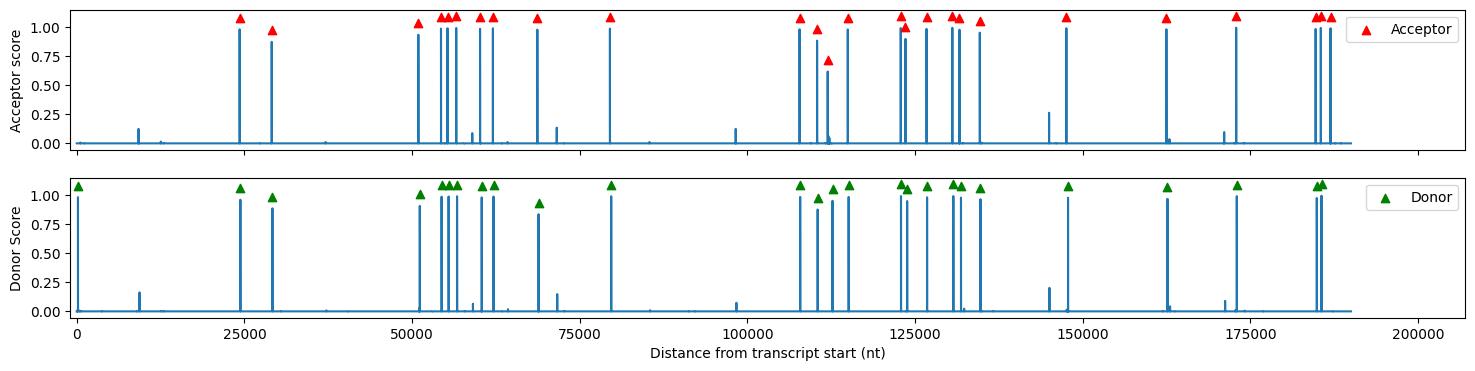

In [106]:
fig, (ax1, ax2) = plt.subplots(2, 1,figsize=(18, 4),sharex=True)
ax1.plot(Y_pred_acceptor)
ax2.plot(Y_pred_donor)
cond = (Y_true_acceptor==1)
ax1.scatter(np.where(Y_true_acceptor==1),Y_pred_acceptor[cond]+0.1,c='red',marker="^", clip_on=False, zorder=10,label='Acceptor')
cond = (Y_true_donor==1)
ax2.scatter(np.where(Y_true_donor==1),Y_pred_donor[cond]+0.1,c='green',marker="^", clip_on=False, zorder=10,label='Donor')
plt.xlabel('Distance from transcript start (nt)')
ax1.set_ylabel('Acceptor score')
ax1.set_xlim([-1000,207000])
ax2.set_ylabel('Donor Score')
ax1.legend()
ax2.legend()
print('Donor distance from transcript start: ', np.where(Y_true_donor==1))
print('Acceptor distance from transcript start: ', np.where(Y_true_acceptor==1))

# plt.savefig('../Results/Transformer_CFTR_scores.png', dpi=400)
plt.show()

In [4]:
CL_max = 10000
SL = 5000
device = torch.device("cpu")
model_m = SpliceAI_10K(CL_max)
model_m.apply(keras_init)
model_m = model_m.to(device)
n_models = 10

if torch.cuda.device_count() > 1:
    model_m = nn.DataParallel(model_m)
model_m = nn.DataParallel(model_m)

models = [copy.deepcopy(model_m) for i in range(n_models)]
[model.load_state_dict(torch.load('../Results/PyTorch_Models/spliceai_encoder_10k_191022_{}'.format(i), map_location=device)) for i,model in enumerate(models)]
for model in models:
    model.eval()

test_dataset = spliceDataset(getDataPointListFull(specific_anno,transcriptToLabel_test,SL,CL_max,shift=SL))
test_dataset.seqData = seqData
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

Y_true_acceptor, Y_pred_acceptor = [],[]
Y_true_donor, Y_pred_donor = [],[]
l = 1
for i,(batch_chunks,target_chunks) in enumerate(tqdm(test_loader)):
    batch_features = batch_chunks.type(torch.FloatTensor).to(device)
    targets = target_chunks.to(device)[:,:,CL_max//2:-CL_max//2]
    outputs = ([models[i](batch_features).detach() for i in range(n_models)])
    print(outputs[0].shape)
    #outputs = (outputs[0]+outputs[1]+outputs[2]+outputs[3]+outputs[4])/n_models
    outputs = torch.stack(outputs)
    outputs = torch.mean(outputs,dim=0)
    #outputs = odds_gmean(outputs)
    #targets_list.extend(targets.unsqueeze(0))
    #outputs_list.extend(outputs.unsqueeze(0))

    targets = torch.transpose(targets,1,2).cpu().numpy()
    outputs = torch.transpose(outputs,1,2).cpu().numpy()

    is_expr = (targets.sum(axis=(1,2)) >= 1)
    Y_true_acceptor.extend(targets[is_expr, :, 1].flatten())
    Y_true_donor.extend(targets[is_expr, :, 2].flatten())
    Y_pred_acceptor.extend(outputs[is_expr, :, 1].flatten())
    Y_pred_donor.extend(outputs[is_expr, :, 2].flatten())

    # l += 1
    # if l>1:
    #     break
Y_true_acceptor, Y_pred_acceptor = np.array(Y_true_acceptor), np.array(Y_pred_acceptor)
Y_true_donor, Y_pred_donor = np.array(Y_true_donor), np.array(Y_pred_donor)

  0%|          | 0/38 [00:00<?, ?it/s]/Users/douglasflorizone/Summer 2025 Research/Code/Spliceformer/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
  3%|▎         | 1/38 [00:01<00:56,  1.52s/it]

torch.Size([1, 3, 5000])


  5%|▌         | 2/38 [00:03<00:54,  1.52s/it]

torch.Size([1, 3, 5000])


  8%|▊         | 3/38 [00:04<00:52,  1.51s/it]

...

torch.Size([1, 3, 5000])


 97%|█████████▋| 37/38 [00:56<00:01,  1.51s/it]

torch.Size([1, 3, 5000])


100%|██████████| 38/38 [00:57<00:00,  1.52s/it]

torch.Size([1, 3, 5000])


SPLICEAI_10K
Donor distance from transcript start:  (array([   184,  24400,  29179,  51151,  54402,  55448,  56710,  60383,
        62145,  68860,  79692, 107870, 110476, 112694, 115095, 122900,
       123819, 126790, 130706, 131845, 134750, 147807, 162630, 172968,
       184897, 185601]),)
Acceptor distance from transcript start:  (array([ 24290,  29071,  50936,  54313,  55285,  56585,  60137,  62053,
        68678,  79501, 107776, 110390, 111971, 114967, 122863, 123569,
       126711, 130556, 131618, 134650, 147559, 162475, 172879, 184725,
       185496, 186945]),)


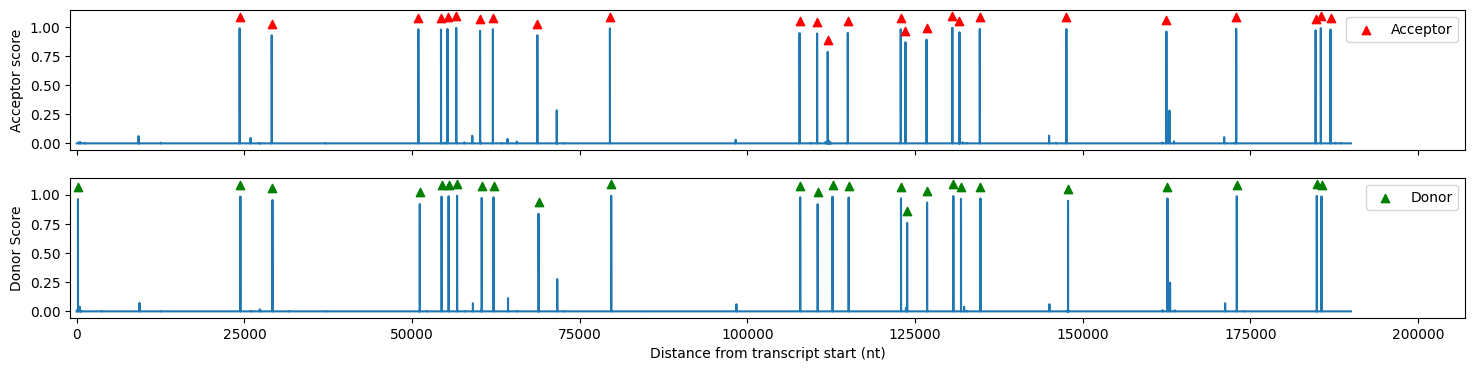

In [5]:
print('SPLICEAI_10K')
fig, (ax1, ax2) = plt.subplots(2, 1,figsize=(18, 4),sharex=True)
ax1.plot(Y_pred_acceptor)
ax2.plot(Y_pred_donor)
cond = (Y_true_acceptor==1)
ax1.scatter(np.where(Y_true_acceptor==1),Y_pred_acceptor[cond]+0.1,c='red',marker="^", clip_on=False, zorder=10,label='Acceptor')
cond = (Y_true_donor==1)
ax2.scatter(np.where(Y_true_donor==1),Y_pred_donor[cond]+0.1,c='green',marker="^", clip_on=False, zorder=10,label='Donor')
plt.xlabel('Distance from transcript start (nt)')
ax1.set_ylabel('Acceptor score')
ax1.set_xlim([-1000,207000])
ax2.set_ylabel('Donor Score')
ax1.legend()
ax2.legend()
print('Donor distance from transcript start: ', np.where(Y_true_donor==1))
print('Acceptor distance from transcript start: ', np.where(Y_true_acceptor==1))

# plt.savefig('../Results/Transformer_CFTR_scores.png', dpi=400)
plt.show()